对应 `tf.keras` 的01~02章节

In [2]:
# 导入 matplotlib 库，并赋予简写名 mpl
import matplotlib as mpl
# 导入 matplotlib 的 pyplot 模块，用于绘图
import matplotlib.pyplot as plt
# 在 Jupyter Notebook 中，我们经常需要直接在单元格下方展示图片或图表
# "%matplotlib inline" 是一种 Jupyter 魔法命令（以百分号 % 开头），可以让 matplotlib 绘制的图像直接嵌入到 Notebook 的输出区，而不是弹出独立的窗口
# 这样可以实现代码即写即看，非常方便数据分析和可视化展示
%matplotlib inline
# 导入 numpy 库，用于科学计算
import numpy as np
# 导入 scikit-learn 库，常用于机器学习相关工具
import sklearn
# 导入 pandas 库，用于数据分析和处理
import pandas as pd
# 导入 os 系统库，用于与操作系统交互
import os
# 导入 sys 系统库，用于访问与 Python 解释器紧密相关的变量和函数
import sys
# 导入 time 库，用于计时等时间相关操作
import time
# 导入 tqdm 库中的 auto 子模块，用于显示进度条（如训练过程等）
from tqdm.auto import tqdm
# 导入 PyTorch 主库
import torch
# 导入 torch.nn 模块，包含神经网络的各类层定义
import torch.nn as nn
# 导入 torch.nn.functional，包含各类激活函数及损失函数等
import torch.nn.functional as F

# 打印当前的 Python 解释器版本信息
print(sys.version_info)
# 循环打印常用库的名称和版本号，便于环境检查和复现
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 检查 CUDA 是否可用，如果有可用的 GPU 则用 GPU，否则用 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
# 打印所用设备（GPU 还是 CPU）
print(device)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


In [3]:
28*28

784

## 数据准备1，为了看灰度图片

In [4]:
from torchvision import datasets  # 提供常用数据集加载接口
from torchvision.transforms import ToTensor  # 转为Tensor、归一化等常用变换
from torchvision import transforms  # 组合多种变换

# 定义数据集的变换（这里仅作示例，未实际应用于后续数据集加载）
# 若想显示原始PIL图片，则不要加ToTensor()或其他变换
transform = transforms.Compose([
    # transforms.ToTensor(),  # 若取消注释，将PIL图片转换为FloatTensor, 并归一化到[0,1]
    # 可以提前做归一化 transforms.Normalize(mean=[0.5], std=[0.5])，视项目需求而定
])
print("定义的transform类型:", type(transform))

# ==============================
# 加载FashionMNIST数据集
# ==============================
# 1. 训练集（60000张 28x28 灰度图片，类别标签0~9）
train_ds = datasets.FashionMNIST(
    root="./data",            # 数据存放路径
    train=True,             # 训练集
    download=True,          # 若本地没有则自动下载
    transform=None          # 不进行任何变换（返回的是PIL.Image和int标签）
)
print("训练集类型:", type(train_ds))  # <class 'torchvision.datasets.mnist.FashionMNIST'>
print("训练集样本数:", len(train_ds))  # 60000
print("单个样本类型:", type(train_ds[0]))  # tuple
print("第一个训练集图片的类型:", type(train_ds[0][0]))  # <class 'PIL.Image.Image'>
print("第一个训练集标签类型:", type(train_ds[0][1]))    # <class 'int'>

# 2. 测试集（10000张 28x28 灰度图片，类别标签0~9）
test_ds = datasets.FashionMNIST(
    root="data",            # 数据存放路径
    train=False,            # 测试集
    download=True,          # 若本地没有则自动下载
    transform=None          # 不进行任何变换
)
print("测试集类型:", type(test_ds))    # <class 'torchvision.datasets.mnist.FashionMNIST'>
print("测试集样本数:", len(test_ds))    # 10000
print("单个样本类型:", type(test_ds[0])) # tuple
print("第一个测试集图片的类型:", type(test_ds[0][0]))  # <class 'PIL.Image.Image'>
print("第一个测试集标签类型:", type(test_ds[0][1]))    # <class 'int'>

# 说明：torchvision官方FashionMNIST数据集没有直接划分验证集，
# 如需 “训练/验证/测试” 可使用 torch.utils.data.random_split 或 Dataset 子类自定义划分

定义的transform类型: <class 'torchvision.transforms.transforms.Compose'>
训练集类型: <class 'torchvision.datasets.mnist.FashionMNIST'>
训练集样本数: 60000
单个样本类型: <class 'tuple'>
第一个训练集图片的类型: <class 'PIL.Image.Image'>
第一个训练集标签类型: <class 'int'>
测试集类型: <class 'torchvision.datasets.mnist.FashionMNIST'>
测试集样本数: 10000
单个样本类型: <class 'tuple'>
第一个测试集图片的类型: <class 'PIL.Image.Image'>
第一个测试集标签类型: <class 'int'>


In [5]:
type(train_ds)

torchvision.datasets.mnist.FashionMNIST

In [6]:
len(train_ds) #60000训练样本

60000

In [7]:
type(train_ds[0])

tuple

In [8]:
# 通过id取数据，取到的是一个元祖,是第一个样本,在训练时，把特征和标签分开
img, label = train_ds[0]

In [9]:
type(img) #tensor中文是 张量,和numpy的ndarray类似

PIL.Image.Image

In [10]:
img

In [11]:
label

9

In [12]:
# 显示图片，这里需要把transforms.ToTensor(),进行归一化注释掉，否则是不行的
def show_img_content(img):
    from PIL import Image

    # 打开一个图像文件
    # img = Image.open(img)


    print("图像大小:", img.size)
    print("图像模式:", img.mode)


    # 如果图像是单通道的，比如灰度图，你可以这样获取像素值列表：
    if img.mode == 'L':
        pixel_values = list(img.getdata())
        print(pixel_values)
show_img_content(img) #这里必须把上面的 transforms.ToTensor(), # 转换为tensor，进行归一化注释掉，否则是不行的

图像大小: (28, 28)
图像模式: L
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 13, 73, 0, 0, 1, 4, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 36, 136, 127, 62, 54, 0, 0, 0, 1, 3, 4, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 102, 204, 176, 134, 144, 123, 23, 0, 0, 0, 0, 12, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 236, 207, 178, 107, 156, 161, 109, 64, 23, 77, 130, 72, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141, 88, 172, 66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245, 173, 0, 0, 0, 

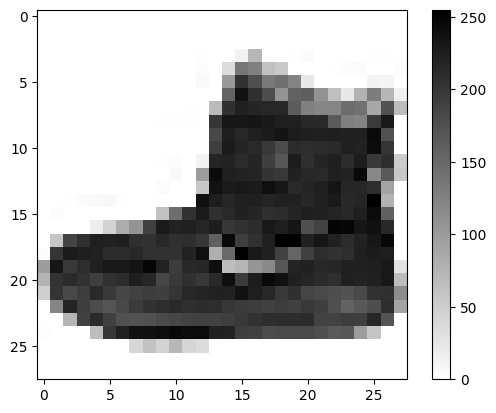

In [13]:
#这个代码必须是注释了上面的 transforms.ToTensor()才能够运行的
def show_single_image(img_arr):
    plt.imshow(img_arr, cmap="binary") # 显示图片
    plt.colorbar() # 显示颜色条
    plt.show()


show_single_image(img)

# 数据准备2，为训练做准备

In [14]:
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision import transforms

# 使用训练集图像的均值和标准差，便于对图像进行归一化处理
mean = 0.2860  # float，训练数据集的像素均值
std = 0.3205   # float，训练数据集的像素标准差

# 定义数据集的图像转换流程
# 返回值类型: torchvision.transforms.Compose
# 作用：将图像转换为Tensor并进行标准化
transform = transforms.Compose([
    transforms.ToTensor(),  # 将PIL Image或numpy.ndarray转换为Tensor，像素值归一化到[0, 1]
    transforms.Normalize(mean, std)  # 用给定的均值和标准差对每个通道做归一化，输出的Tensor
])

# 加载FashionMNIST训练集
# 返回值类型: torchvision.datasets.FashionMNIST
# 作用：下载（如未存在）并加载训练集数据，每个样本返回(img_tensor, label)
train_ds = datasets.FashionMNIST(
    root="data",            # 数据存放的目录
    train=True,             # 是否加载训练集
    download=True,          # 如果数据不存在则自动下载
    transform=transform     # 应用上述定义的图像转换
)

# 加载FashionMNIST测试集
# 返回值类型: torchvision.datasets.FashionMNIST
# 作用：下载（如未存在）并加载测试集数据，每个样本返回(img_tensor, label)
test_ds = datasets.FashionMNIST(
    root="data",            # 数据存放的目录
    train=False,            # 是否加载测试集
    download=True,          # 如果数据不存在则自动下载
    transform=transform     # 应用上述定义的图像转换
)

# 注意：torchvision原生数据集未直接划分训练/验证集，
# 如需验证集，可基于torch.utils.data.Dataset自行划分

In [15]:
img_tensor, label = train_ds[0]
img_tensor.shape  #img这时是一个tensor，shape=(1, 28, 28)

torch.Size([1, 28, 28])

In [16]:
type(img_tensor)

torch.Tensor

In [17]:
label

9

In [18]:
#计算均值和方差
def cal_mean_std(ds):
    mean = 0.
    std = 0.
    for img, _ in ds:  # 遍历每张图片,img.shape=[1,28,28]
        mean += img.mean(dim=(1, 2))  # 计算每张图片的均值，dim=(1, 2)表示计算每张图片的每一个像素的均值,行列共同求均值
        std += img.std(dim=(1, 2))
    mean /= len(ds)
    std /= len(ds)
    return mean, std


print(cal_mean_std(train_ds))


(tensor([0.0001]), tensor([0.9999]))


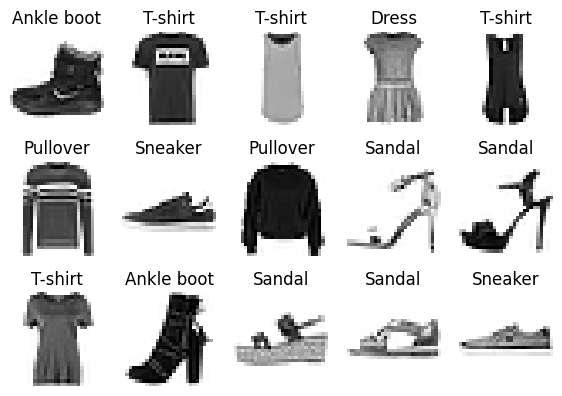

In [19]:
def show_imgs(n_rows, n_cols, train_ds, class_names):
    assert n_rows * n_cols < len(train_ds)  #确保打印的图片小于总样本数
    plt.figure(figsize = (n_cols * 1.4, n_rows * 1.6))  #宽1.4高1.6，宽，高
    for row in range(n_rows):
        for col in range(n_cols):
            index = n_cols * row + col  # 计算索引，从0开始
            plt.subplot(n_rows, n_cols, index+1)#因为从1开始
            img_arr, label = train_ds[index]
            img_arr = np.transpose(img_arr, (1, 2, 0))  # 通道换到最后一维,在画图时需要
            plt.imshow(img_arr, cmap="binary",
                       interpolation = 'nearest')#interpolation='nearest'是临近插值
            plt.axis('off')#去除坐标系
            plt.title(class_names[label]) # 显示类别名称
    plt.show()
    
    

#已知的图片类别
# lables在这个路径https://github.com/zalandoresearch/fashion-mnist
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',
               'Coat', 'Sandal', 'Shirt', 'Sneaker',
               'Bag', 'Ankle boot'] #0-9分别代表的类别
#只是打印了前15个样本
show_imgs(3, 5, train_ds, class_names)


In [20]:
# 使用DataLoader将处理好的数据集封装成迭代器，方便后续按批训练和验证
# train_loader用于训练集，设置batch_size为32，每次迭代返回32条样本，并且将样本顺序打乱（shuffle=True），以提升模型泛化能力
train_loader = torch.utils.data.DataLoader(
    train_ds,              # 训练数据集对象
    batch_size=32,         # 每个批次加载32个样本
    shuffle=True           # 每个epoch开始时打乱数据顺序
) 

# val_loader用于验证集，batch_size同样为32，但不打乱顺序（shuffle=False），保持测试数据的原始排列
val_loader = torch.utils.data.DataLoader(
    test_ds,               # 测试/验证数据集对象
    batch_size=32,         # 每个批次加载32个样本
    shuffle=False          # 不打乱数据，确保验证的可重复性
)

在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。



In [21]:
# for datas, labels in train_loader:
#     print(datas[0])
#     print(labels)
#     break
# #查看val_loader
# for datas, labels in val_loader:
#     print(datas.shape)
#     print(labels.shape)
#     break

## 定义模型

In [37]:
class NeuralNetwork1(nn.Module):
    def __init__(self):
        super().__init__()  # 调用父类nn.Module的初始化
        self.flatten = nn.Flatten()  # 展平层，把输入从[batch_size, 1, 28, 28]变为[batch_size, 784]
        self.l1 = nn.Linear(784, 300) # 第一全连接层，将展平后的输入映射到300维
        self.relu1 = nn.ReLU()        # 第一个ReLU激活层，增加非线性能力
        self.l2 = nn.Linear(300, 100) # 第二全连接层，将300维映射到100维
        self.relu2 = nn.ReLU()        # 第二个ReLU激活层
        self.l3 = nn.Linear(100, 10)  # 输出层，将100维映射到10个类别的输出(logits)

    def forward(self, x):
        """
        定义前向传播过程，依次经过展平、3个线性层及2个ReLU激活层，并打印关键张量信息。

        Args:
            x (torch.Tensor): 输入张量，形状为[batch_size, 1, 28, 28]
        Returns:
            logits (torch.Tensor): 输出未归一化的类别分数logits，形状为[batch_size, 10]
        """
        # 关键步骤和shape的输出
        print(f'输入 x 的shape: {x.shape}')  # 输入原始shape
        x = self.flatten(x)  
        print(f'经过 flatten, x 的shape: {x.shape}')  # 展平后
        x = self.l1(x)
        print(f'经过 l1（第一线性层）, x 的shape: {x.shape}') 
        x = self.relu1(x)
        print(f'经过 relu1（第一ReLU）, x 的shape: {x.shape}') 
        x = self.l2(x)
        print(f'经过 l2（第二线性层）, x 的shape: {x.shape}')
        x = self.relu2(x)
        print(f'经过 relu2（第二ReLU）, x 的shape: {x.shape}')
        logits = self.l3(x)
        print(f'最终输出 logits 的shape: {logits.shape}')  # 最终输出
        return logits  # 返回未归一化logits，shape为[batch_size, 10]

# 实例化模型
model1 = NeuralNetwork1()

# 构造一个输入张量，模拟[32, 1, 28, 28]形状的batch图像
x = torch.randn(32, 1, 28, 28)
print(f'用于测试的输入张量 shape: {x.shape}')  # 打印输入形状，期望为[32, 1, 28, 28]

logits = model1(x)  # 前向传播输出 logits
print(f'前向传播输出 logits 的最终 shape: {logits.shape}') # 打印输出形状，期望为[32, 10]。注意：logits 是模型输出的未归一化得分（即每个类别的原始分数），而不是概率。用于分类时，通常会再经过 softmax 层将 logits 转为概率。

用于测试的输入张量 shape: torch.Size([32, 1, 28, 28])
输入 x 的shape: torch.Size([32, 1, 28, 28])
经过 flatten, x 的shape: torch.Size([32, 784])
经过 l1（第一线性层）, x 的shape: torch.Size([32, 300])
经过 relu1（第一ReLU）, x 的shape: torch.Size([32, 300])
经过 l2（第二线性层）, x 的shape: torch.Size([32, 100])
经过 relu2（第二ReLU）, x 的shape: torch.Size([32, 100])
最终输出 logits 的shape: torch.Size([32, 10])
前向传播输出 logits 的最终 shape: torch.Size([32, 10])


In [23]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        """
        定义一个多层全连接神经网络用于分类任务。
        网络结构：
        - 输入: 784维（28x28像素灰度图像展平）
        - 第一层: 全连接层，输出300维
        - 激活: ReLU
        - 第二层: 全连接层，输出100维
        - 激活: ReLU
        - 第三层: 全连接层，输出10维（代表10个类别的logits）

        组件说明:
        - self.flatten: 用于将多维输入（[batch_size, 1, 28, 28]）展平成二维（[batch_size, 784]）
        - self.linear_relu_stack: 包含三层线性变换和两层ReLU激活
        """
        super().__init__()  # 继承父类nn.Module的初始化方法
        self.flatten = nn.Flatten()  # 展平层,将输入从[batch, 1, 28, 28]转换为[batch, 784]
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784, 300),  # 第一层: 输入784维, 输出300维
            nn.ReLU(),            # 激活函数
            nn.Linear(300, 100),  # 第二层: 输入300维, 输出100维
            nn.ReLU(),            # 激活函数
            nn.Linear(100, 10),   # 第三层: 输入100维, 输出10维（对应类别数）
        )

    def forward(self, x) -> torch.Tensor:
        """
        前向传播函数，定义了数据经过网络的路径。
        
        参数:
            x (torch.Tensor): 输入张量, 形状为[batch_size, 1, 28, 28]
        
        返回:
            torch.Tensor: 输出未经过softmax的logits, 形状为[batch_size, 10]
        """
        x = self.flatten(x)               # 展平输入, 得到形状[batch_size, 784]
        logits = self.linear_relu_stack(x) # 依次通过全连接层和ReLU激活
        return logits  # 返回类别分数（logits）
    
model = NeuralNetwork()

In [30]:
# 看看网络结构
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Linear(in_features=300, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [31]:
#为了查看模型运算的tensor尺寸
x = torch.randn(32, 1, 28, 28)
print(x.shape)
logits = model(x) # 前向传播，做模型验证
print(logits.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


In [32]:
784*300+300+300*100+100+100*10+10

266610

In [33]:
for name, param in model.named_parameters(): # 打印模型参数
      print(name, param.shape)

linear_relu_stack.0.weight torch.Size([300, 784])
linear_relu_stack.0.bias torch.Size([300])
linear_relu_stack.2.weight torch.Size([100, 300])
linear_relu_stack.2.bias torch.Size([100])
linear_relu_stack.4.weight torch.Size([10, 100])
linear_relu_stack.4.bias torch.Size([10])


In [34]:
for p in model.parameters():
    print(p.shape)

torch.Size([300, 784])
torch.Size([300])
torch.Size([100, 300])
torch.Size([100])
torch.Size([10, 100])
torch.Size([10])


In [35]:
#帮我计算模型总参数量
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 266,610


In [36]:
# 看看模型参数
list(model.parameters())  # 这种方法拿到模型的所有可学习参数,requires_grad=True


[Parameter containing:
 tensor([[-0.0025,  0.0219, -0.0014,  ..., -0.0058,  0.0278,  0.0108],
         [-0.0205,  0.0345, -0.0062,  ..., -0.0184, -0.0336,  0.0330],
         [-0.0136,  0.0243, -0.0054,  ...,  0.0312,  0.0199,  0.0308],
         ...,
         [-0.0038, -0.0334, -0.0096,  ...,  0.0336,  0.0287, -0.0291],
         [ 0.0046,  0.0203, -0.0281,  ..., -0.0094, -0.0326, -0.0115],
         [ 0.0150,  0.0279,  0.0237,  ...,  0.0014, -0.0304,  0.0213]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0295,  0.0128, -0.0163,  0.0141, -0.0103,  0.0021, -0.0112,  0.0318,
         -0.0337, -0.0096,  0.0169,  0.0343,  0.0130,  0.0142,  0.0255,  0.0055,
         -0.0286,  0.0138,  0.0208, -0.0318, -0.0026, -0.0168, -0.0322,  0.0037,
          0.0292,  0.0148, -0.0169,  0.0188, -0.0219,  0.0342,  0.0195,  0.0095,
          0.0113,  0.0276, -0.0223, -0.0098, -0.0049,  0.0167,  0.0009, -0.0023,
         -0.0137,  0.0348, -0.0181, -0.0046,  0.0313, -0.0096,  0.0145, -0.0113

In [37]:
np.sqrt(1/784)

np.float64(0.03571428571428571)

In [38]:
# model.state_dict()  # 这种方法用于保存模型参数，看能看见参数属于模型的哪一部分

## 训练

pytorch的训练需要自行实现，包括
1. 定义损失函数
2. 定义优化器
3. 定义训练步
4. 训练

In [39]:
# 1. 定义损失函数 采用交叉熵损失
loss_fct = nn.CrossEntropyLoss() #内部先做softmax，然后计算交叉熵
# 2. 定义优化器 采用SGD
# Optimizers specified in the torch.optim package,随机梯度下降
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [40]:
10000/32

312.5

In [36]:
#随机一个1个数的tensor
t=torch.randn(1)
t.item()

1.3890128135681152

In [42]:
#一个(32,10)的tensor求argmax的例子
t=torch.randn(32,10)
t.argmax(axis=-1).shape

torch.Size([32])

In [43]:
from sklearn.metrics import accuracy_score

@torch.no_grad() # 装饰器，禁止反向传播，节省内存
def evaluating(model, dataloader, loss_fct):
    loss_list = [] # 记录损失
    pred_list = [] # 记录预测
    label_list = [] # 记录标签
    for datas, labels in dataloader:#10000/32=312
        datas = datas.to(device) # 把tensor放入GPU
        labels = labels.to(device) # 转到GPU
        # 前向计算
        logits = model(datas)
        loss = loss_fct(logits, labels)         # 验证集损失,loss尺寸是一个数值
        loss_list.append(loss.item()) # 记录损失,item是把tensor转换为数值
        
        preds = logits.argmax(axis=-1)    # 验证集预测,argmax返回最大值索引
        # print(f'评估中的preds.shape{preds.shape}')
        pred_list.extend(preds.cpu().numpy().tolist())#将PyTorch张量转换为NumPy数组。只有当张量在CPU上时，这个转换才是合法的
        # print(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())
        
    acc = accuracy_score(label_list, pred_list) # 计算准确率
    return np.mean(loss_list), acc


In [44]:
1875*20

37500

In [45]:
# 训练
def training(model, train_loader, val_loader, epoch, loss_fct, optimizer, eval_step=500):
    record_dict = {
        "train": [],
        "val": []
    }
    
    global_step = 0
    model.train()
    #tqdm是一个进度条库
    with tqdm(total=epoch * len(train_loader)) as pbar: # 进度条 1875*20,60000/32=1875
        for epoch_id in range(epoch): # 训练epoch次
            # training
            for datas, labels in train_loader: #执行次数是60000/32=1875
                datas = datas.to(device) #datas尺寸是[batch_size,1,28,28]
                labels = labels.to(device) #labels尺寸是[batch_size]
                # 梯度清空
                optimizer.zero_grad()
                # 模型前向计算
                logits = model(datas)
                # 计算损失
                loss = loss_fct(logits, labels)
                # 梯度回传，loss.backward()会计算梯度，loss对模型参数w,b求导
                loss.backward()
                # 调整优化器，包括学习率的变动等,优化器的学习率会随着训练的进行而减小，更新w,b
                optimizer.step() #梯度是计算并存储在模型参数的 .grad 属性中，优化器使用这些存储的梯度来更新模型参数

                preds = logits.argmax(axis=-1) # 训练集预测
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())   # 计算准确率，numpy可以,batch_size的准确率
                loss = loss.cpu().item() # 损失转到CPU，item()取值,一个数值
                # record
                # record
                
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                }) # 记录训练集信息，每一步的损失，准确率，步数
                
                # evaluating
                if global_step % eval_step == 0:
                    model.eval() # 进入评估模式
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train() # 进入训练模式

                # udate step
                global_step += 1 # 全局步数加1
                pbar.update(1) # 更新进度条
                pbar.set_postfix({"epoch": epoch_id}) # 设置进度条显示信息
        
    return record_dict
        

epoch = 20 #改为40
model = model.to(device)
record = training(model, train_loader, val_loader, epoch, loss_fct, optimizer, eval_step=1000)

  0%|          | 0/37500 [00:00<?, ?it/s]

In [ ]:
record["train"][-5:]

[{'loss': 0.11753986775875092, 'acc': 0.96875, 'step': 37495},
 {'loss': 0.15016040205955505, 'acc': 0.90625, 'step': 37496},
 {'loss': 0.293830007314682, 'acc': 0.875, 'step': 37497},
 {'loss': 0.2704658508300781, 'acc': 0.875, 'step': 37498},
 {'loss': 0.1676606386899948, 'acc': 0.90625, 'step': 37499}]

In [ ]:
record["val"][-5:]

[{'loss': 0.3572854406822223, 'acc': 0.8733, 'step': 33000},
 {'loss': 0.3644893285565483, 'acc': 0.87, 'step': 34000},
 {'loss': 0.3662031513100234, 'acc': 0.8706, 'step': 35000},
 {'loss': 0.35802577741848773, 'acc': 0.8716, 'step': 36000},
 {'loss': 0.35424996783939033, 'acc': 0.873, 'step': 37000}]

step
0        0.18750
1000     0.59375
2000     0.65625
3000     0.87500
4000     0.87500
5000     0.84375
6000     0.84375
7000     0.84375
8000     0.78125
9000     0.78125
10000    0.87500
11000    0.87500
12000    0.81250
13000    0.84375
14000    0.96875
15000    0.87500
16000    0.93750
17000    0.87500
18000    0.84375
19000    0.84375
20000    0.84375
21000    0.90625
22000    0.90625
23000    0.93750
24000    0.87500
25000    0.90625
26000    0.78125
27000    0.93750
28000    0.81250
29000    0.90625
30000    0.96875
31000    0.90625
32000    0.87500
33000    0.96875
34000    0.84375
35000    0.87500
36000    0.78125
37000    0.84375
Name: acc, dtype: float64
step
0        0.1382
1000     0.6862
2000     0.7679
3000     0.7902
4000     0.7998
5000     0.8091
6000     0.8100
7000     0.8268
8000     0.8344
9000     0.8348
10000    0.8429
11000    0.8453
12000    0.8433
13000    0.8481
14000    0.8505
15000    0.8508
16000    0.8497
17000    0.8568
18000    0.8590
19000    0.857

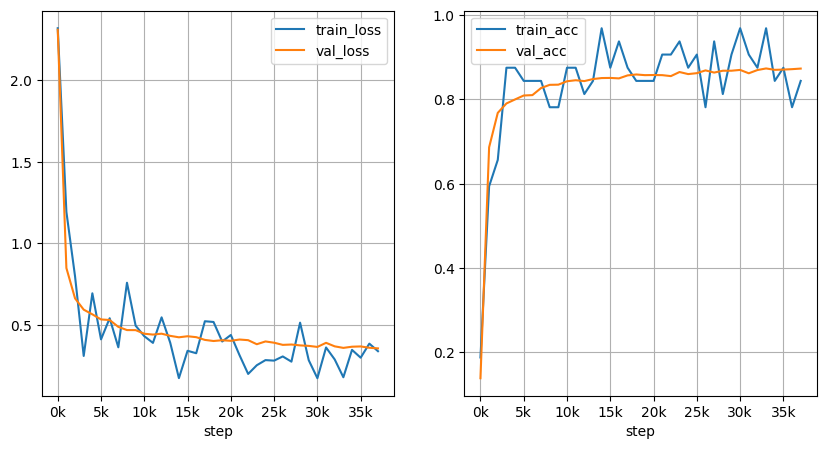

In [ ]:
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=1000):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    last_step = train_df.index[-1] # 最后一步的步数
    # print(train_df.columns)
    print(train_df['acc'])
    print(val_df['acc'])
    # plot
    fig_num = len(train_df.columns) # 画几张图,分别是损失和准确率
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):
        # print(train_df[item].values)
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid() # 显示网格
        axs[idx].legend() # 显示图例
        axs[idx].set_xticks(range(0, train_df.index[-1], 5000)) # 设置x轴刻度
        axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, last_step, 5000))) # 设置x轴标签
        axs[idx].set_xlabel("step")
    
    plt.show()

plot_learning_curves(record)  #横坐标是 steps

## 评估

In [ ]:
# dataload for evaluating

model.eval() # 进入评估模式
loss, acc = evaluating(model, val_loader, loss_fct)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.3469
accuracy: 0.8745
